# 02 · Análisis exploratorio de datos (EDA)

**Objetivo.** Entender la estructura del dataset y validar hipótesis futbolísticas antes de modelar: ¿cómo varía la probabilidad de gol con la distancia y el ángulo?, ¿qué desbalanceo de clases existe?, ¿qué relaciones espaciales hay?


In [1]:
# Bootstrap: hace importable el paquete `xg` desde notebooks/ (src layout)
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == 'notebooks') else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from xg import config, features, models, analysis, visualization
from xg import data as data_loader
from xg.models import evaluation, statistics
pd.set_option('display.float_format', lambda v: f'{v:0.4f}')
config.ensure_dirs()
np.random.seed(config.RANDOM_STATE)
print('Proyecto:', config.PROJECT_ROOT.name)

Proyecto: TFM_xG_MachineLearning


In [2]:
raw, source = data_loader.build_shots_dataframe(source='auto')
feat = features.engineer_features(raw)
print('Fuente:', source, '| disparos:', len(feat))

Fuente: statsbomb | disparos: 5829


## 2.1 Desbalanceo de clases
El gol es un evento raro. Esto condiciona la elección de métricas (Brier/LogLoss/PR-AUC sobre accuracy) y el tratamiento del desbalanceo.

Tasa de gol: 0.1131


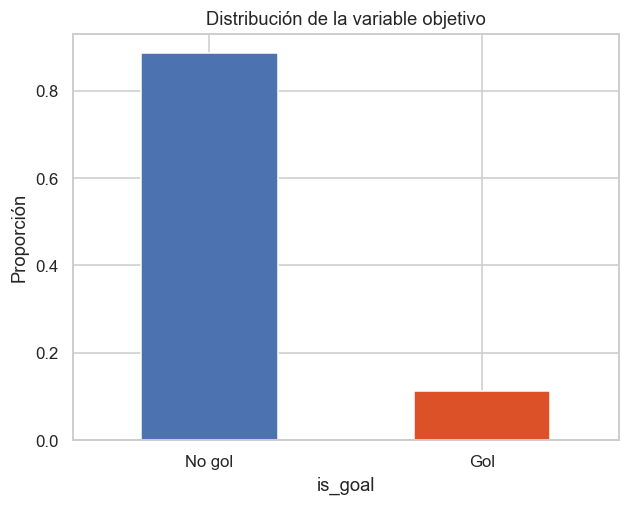

In [3]:
ax = feat['is_goal'].value_counts(normalize=True).plot.bar(color=['#4c72b0','#dd5129'])
ax.set_xticklabels(['No gol','Gol'], rotation=0); ax.set_ylabel('Proporción')
ax.set_title('Distribución de la variable objetivo'); plt.show()
print('Tasa de gol:', round(feat['is_goal'].mean(),4))

## 2.2 Relación distancia / ángulo con la probabilidad de gol
Discretizamos distancia y ángulo y calculamos la tasa de gol empírica: debe **decaer con la distancia** y **crecer con el ángulo**.

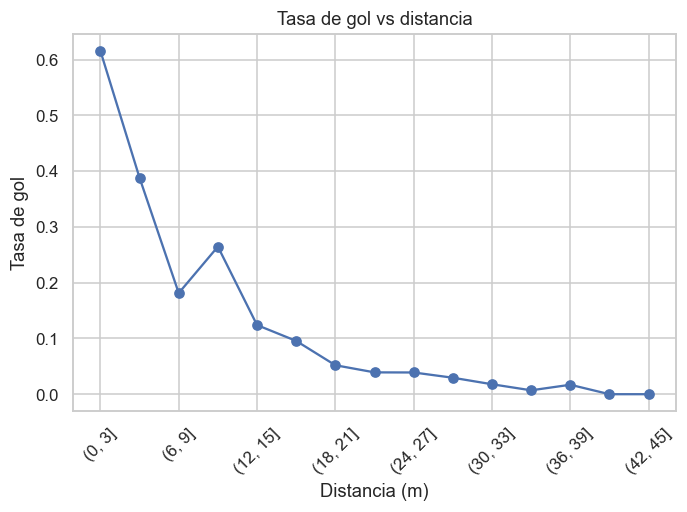

In [4]:
import numpy as np
feat['dist_bin'] = pd.cut(feat['distance_to_goal'], bins=np.arange(0,46,3))
rate = feat.groupby('dist_bin', observed=True)['is_goal'].mean()
rate.plot(marker='o'); plt.ylabel('Tasa de gol'); plt.xlabel('Distancia (m)')
plt.title('Tasa de gol vs distancia'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

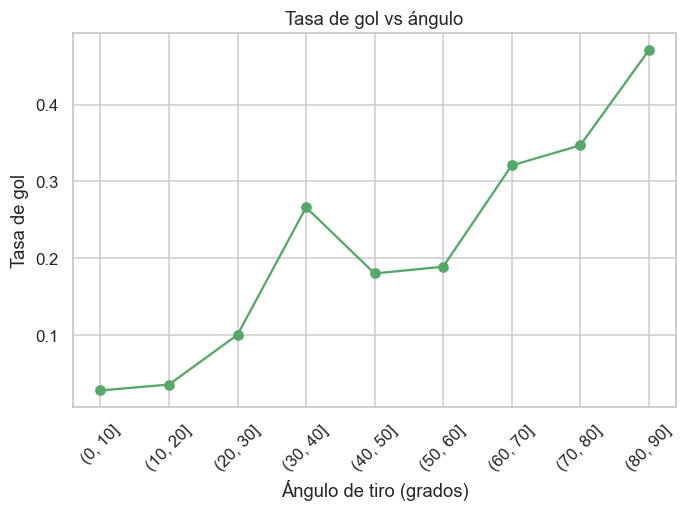

In [5]:
feat['ang_bin'] = pd.cut(np.degrees(feat['shot_angle']), bins=np.arange(0,95,10))
rate_a = feat.groupby('ang_bin', observed=True)['is_goal'].mean()
rate_a.plot(marker='o', color='#55a868'); plt.ylabel('Tasa de gol')
plt.xlabel('Ángulo de tiro (grados)'); plt.title('Tasa de gol vs ángulo')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 2.3 Mapa de disparos y mapa de calor
Visualización espacial de los disparos sobre el campo (convención StatsBomb).

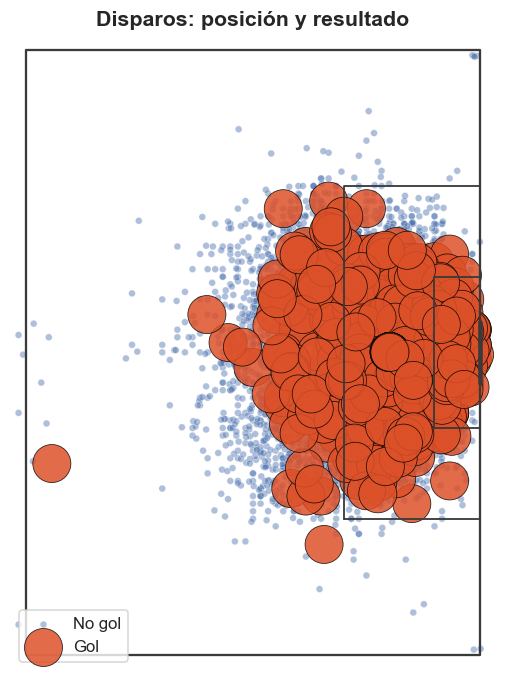

In [6]:
scored_demo = feat.copy(); scored_demo['xg_pred'] = scored_demo['is_goal'].astype(float)
visualization.plot_shot_map(scored_demo, prob_col='xg_pred',
    title='Disparos: posición y resultado', save_as='eda_shot_map'); plt.show()

## 2.4 Matriz de correlación de variables numéricas
Detecta colinealidad (p. ej. distancia vs log-distancia) y orienta la selección/regularización.

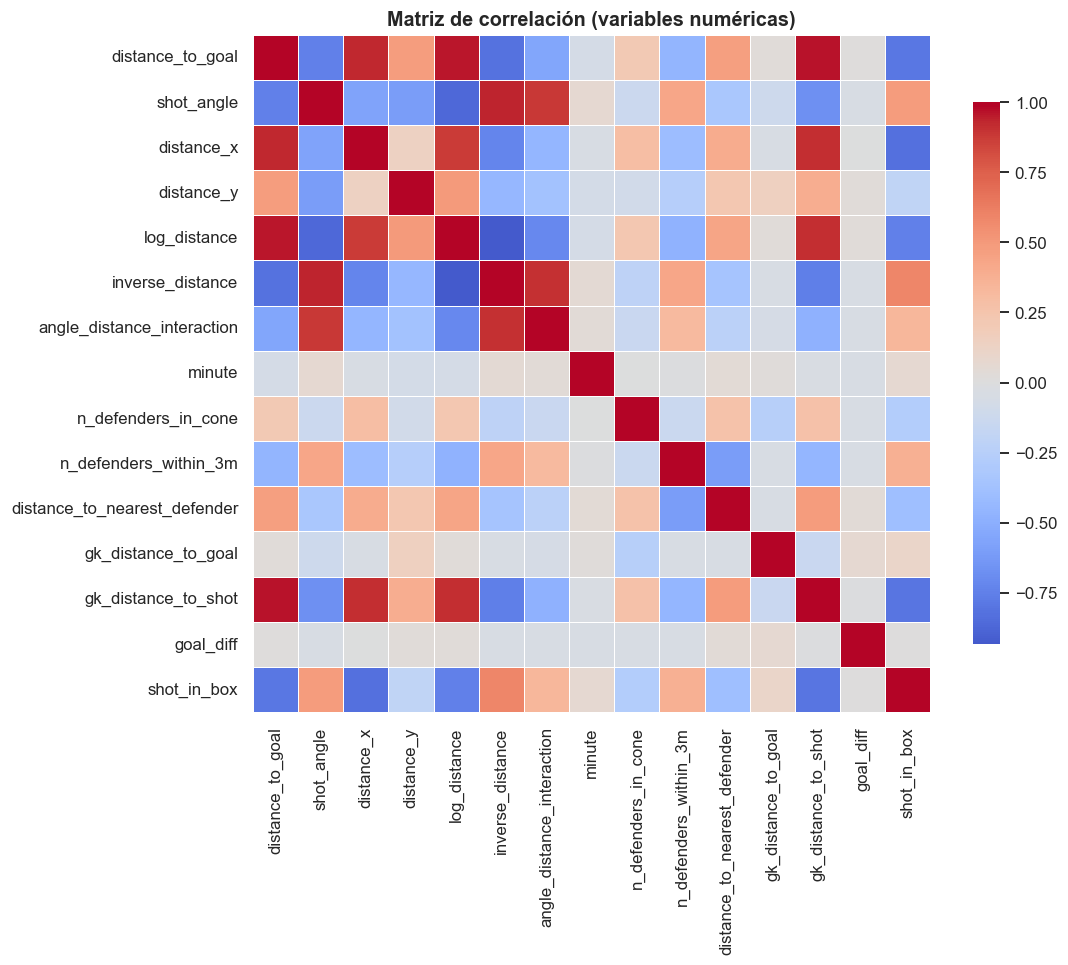

In [7]:
visualization.plot_correlation_matrix(feat, config.NUMERIC_FEATURES, save_as='eda_correlation'); plt.show()

**Conclusiones del EDA.**
* Fuerte desbalanceo → priorizar métricas probabilísticas y de ranking.
* La probabilidad de gol decae con la distancia y crece con el ángulo, confirmando que la geometría es la base del xG.
* Existe colinealidad esperable entre variables geométricas derivadas, que se gestiona con regularización (LogReg) o de forma natural en los árboles.